
--- DATA INFO ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4064 entries, 0 to 4063
Data columns (total 27 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   DR_NO              4064 non-null   int64  
 1   Date Rptd          4064 non-null   object 
 2   Date               4064 non-null   object 
 3   Time               4064 non-null   int64  
 4   AREA               4064 non-null   int64  
 5   Area Name          4064 non-null   object 
 6   Rpt Dist No        4064 non-null   int64  
 7   Part 1-2           4064 non-null   int64  
 8   Crm Cd             4064 non-null   int64  
 9   Crime Description  4064 non-null   object 
 10  Vict Age           4064 non-null   int64  
 11  Vict Sex           4064 non-null   object 
 12  Vict Descent       4064 non-null   object 
 13  Premis Cd          4064 non-null   int64  
 14  Premis Desc        4060 non-null   object 
 15  Status             4064 non-null   object 
 16  Statu

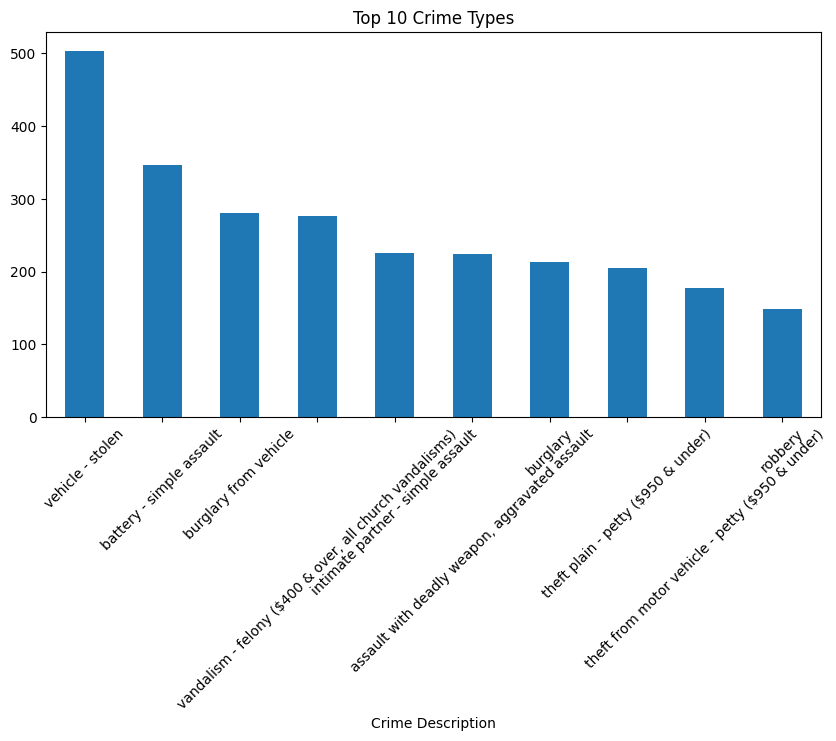

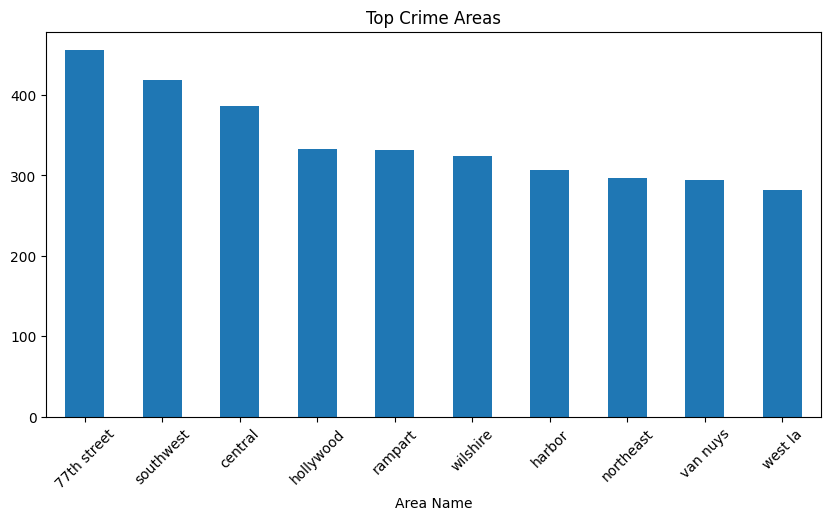

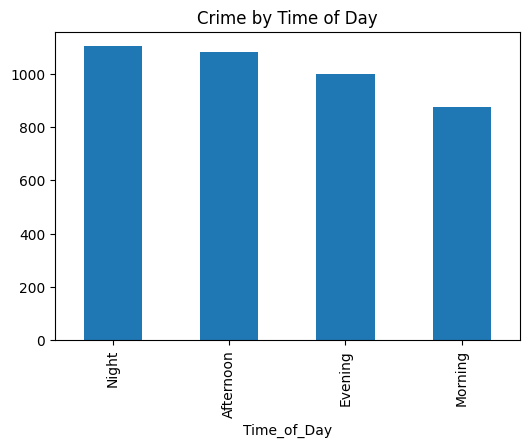

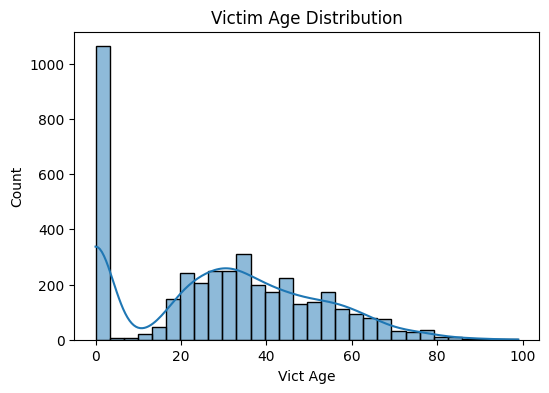

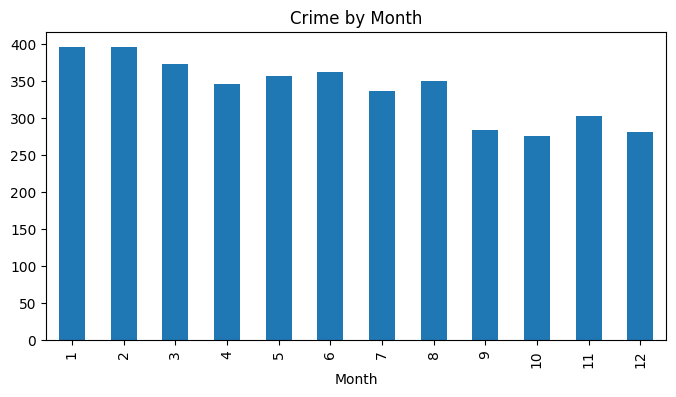

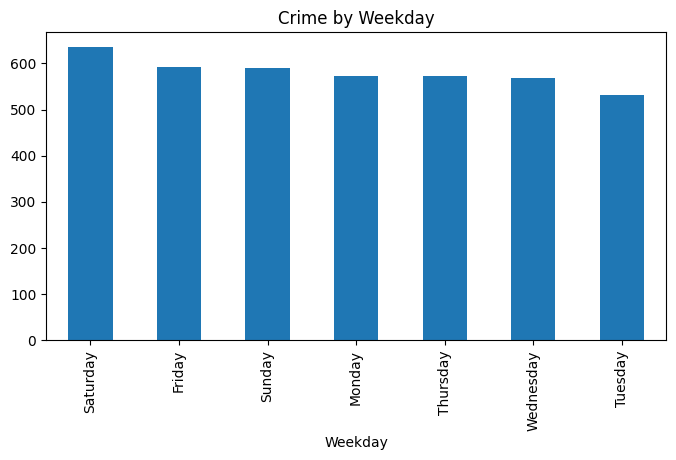

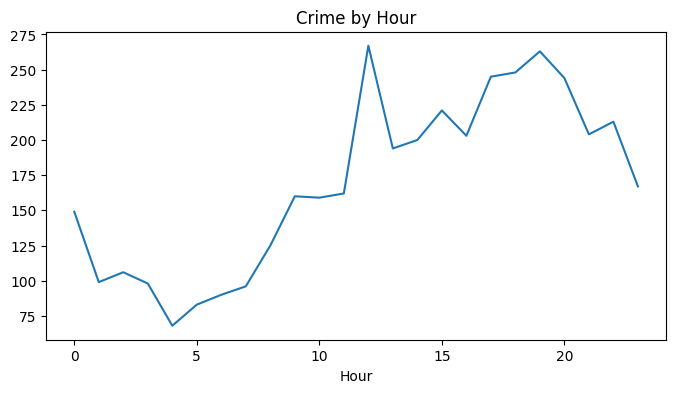

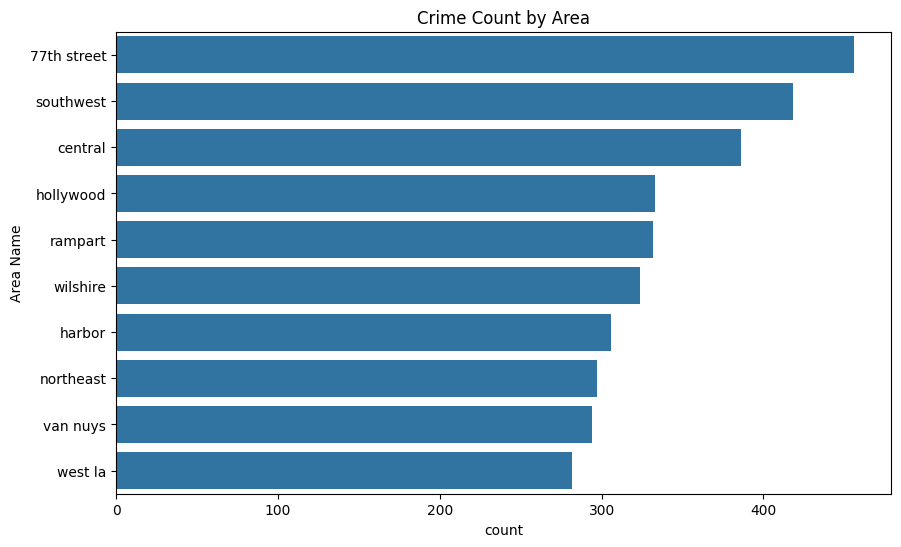

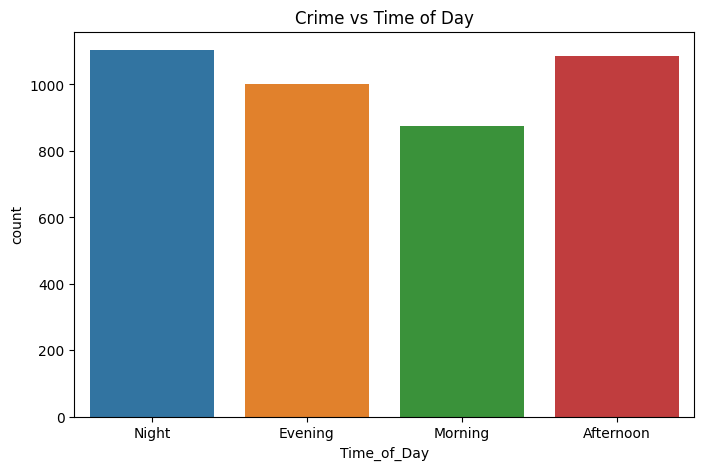

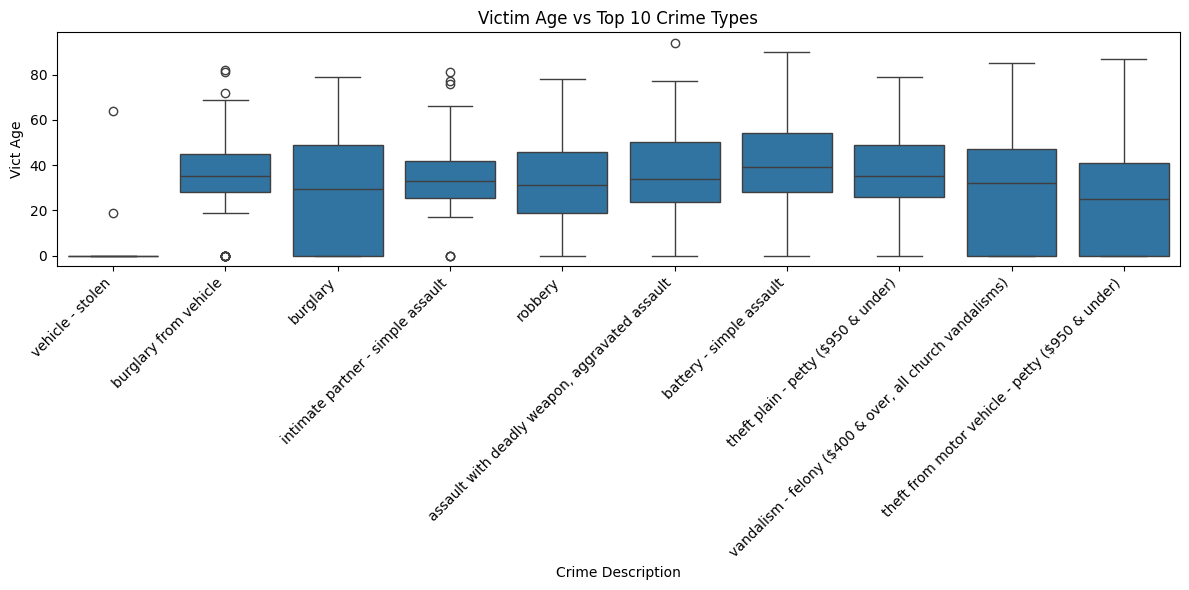

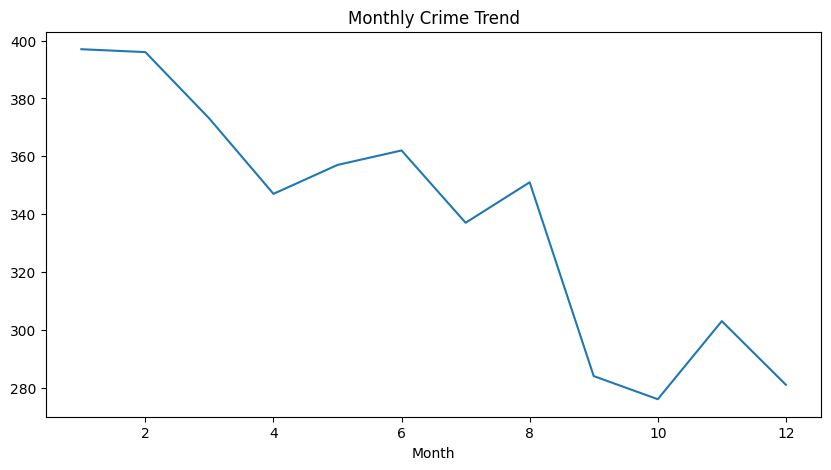

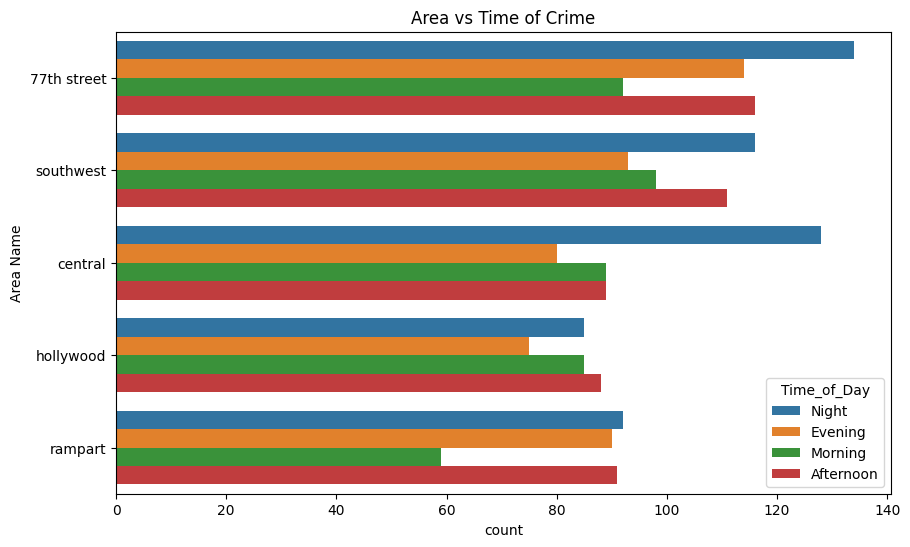

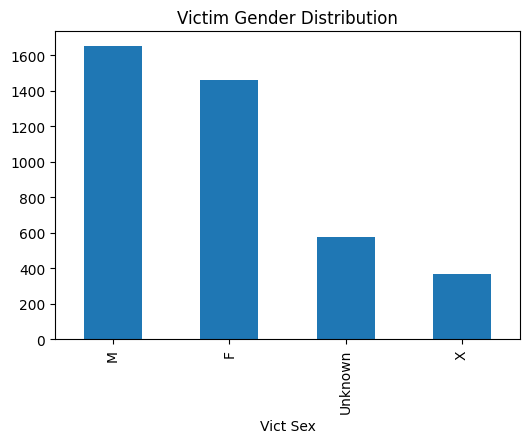

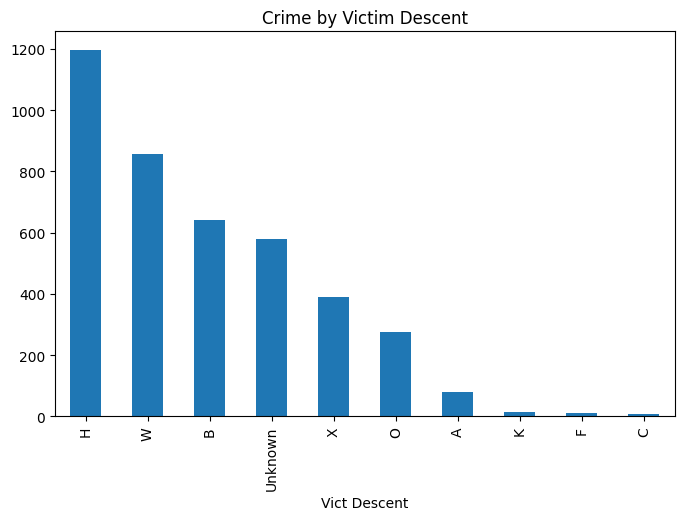

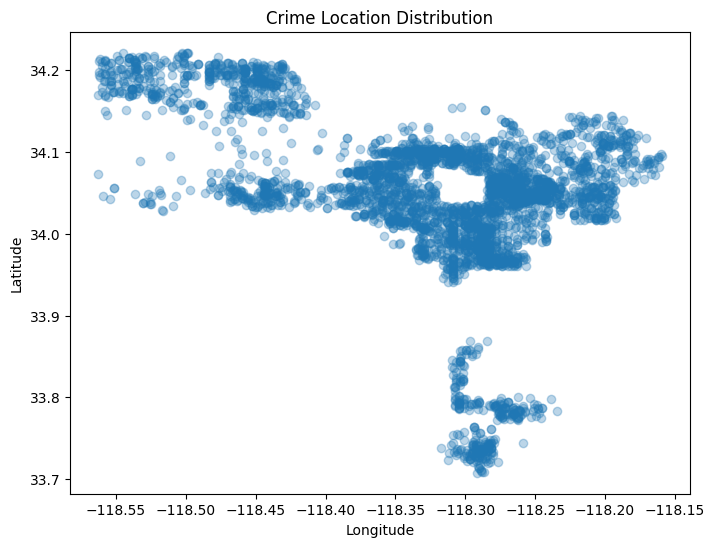

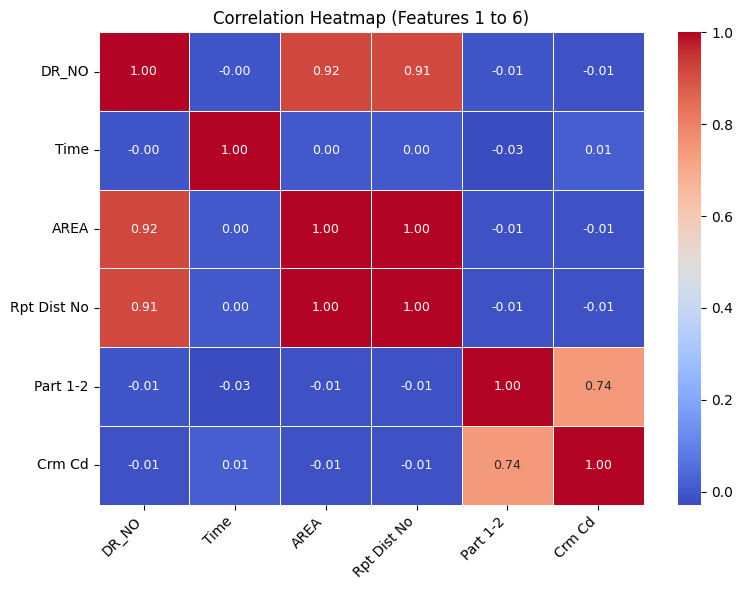

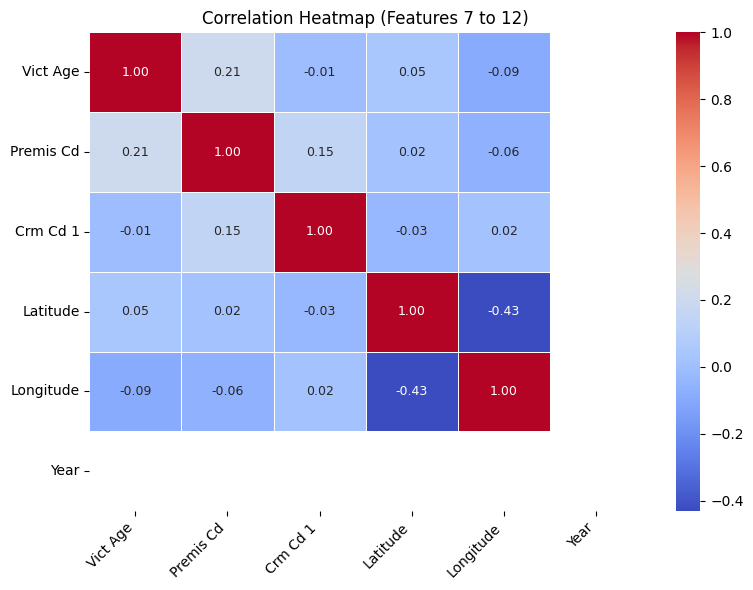

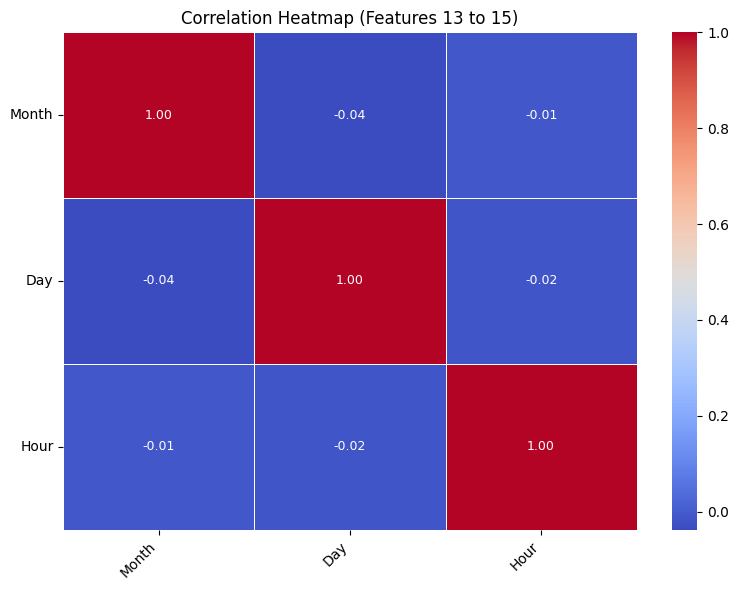


--- TOP 5 CRIME AREAS ---
Area Name
77th street    456
southwest      418
central        386
hollywood      333
rampart        332
Name: count, dtype: int64

--- TOP 5 CRIME TYPES ---
Crime Description
vehicle - stolen                                           504
battery - simple assault                                   347
burglary from vehicle                                      281
vandalism - felony ($400 & over, all church vandalisms)    277
intimate partner - simple assault                          226
Name: count, dtype: int64

--- PEAK CRIME TIME ---
Time_of_Day
Night        1104
Afternoon    1085
Evening      1000
Morning       875
Name: count, dtype: int64

--- SUMMARY STATISTICS ---
              DR_NO                      Date Rptd  \
count  4.064000e+03                           4064   
mean   2.006720e+08  2020-06-23 17:42:38.267716608   
min    1.903265e+08            2020-01-01 00:00:00   
25%    2.003166e+08            2020-03-22 00:00:00   
50%    2.007008e+08    

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore

# -----------------------------
# WEEK 2: LOAD & UNDERSTAND DATA
# -----------------------------
df = pd.read_csv("final_cleaned_crime_data.csv")

# Clean column names
df.columns = df.columns.str.strip()

print("\n--- DATA INFO ---")
print(df.info())

print("\n--- SHAPE ---")
print(df.shape)

print("\n--- MISSING VALUES ---")
print(df.isnull().sum())

print("\n--- FIRST 5 ROWS ---")
print(df.head())

# -----------------------------
# WEEK 3: DATA CLEANING VALIDATION
# -----------------------------

# Convert date columns
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df['Date Rptd'] = pd.to_datetime(df['Date Rptd'], errors='coerce')

# Remove invalid locations
df = df[(df['Latitude'] != 0) & (df['Longitude'] != 0)]

# Handle missing values
df['Vict Sex'] = df['Vict Sex'].fillna('Unknown')
df['Vict Descent'] = df['Vict Descent'].fillna('Unknown')

# Drop rows with missing crime description
df = df.dropna(subset=['Crime Description'])

# -----------------------------
# WEEK 4: EDA (15 IMPORTANT VISUALIZATIONS)
# -----------------------------

import matplotlib.pyplot as plt
import seaborn as sns

# ---------- UNIVARIATE (7) ----------

# 1. Crime Type Distribution
plt.figure(figsize=(10,5))
df['Crime Description'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Crime Types")
plt.xticks(rotation=45)
plt.show()

# 2. Area Distribution
plt.figure(figsize=(10,5))
df['Area Name'].value_counts().head(10).plot(kind='bar')
plt.title("Top Crime Areas")
plt.xticks(rotation=45)
plt.show()

# 3. Time of Day Distribution
plt.figure(figsize=(6,4))
df['Time_of_Day'].value_counts().plot(kind='bar')
plt.title("Crime by Time of Day")
plt.show()

# 4. Victim Age Distribution
plt.figure(figsize=(6,4))
sns.histplot(df['Vict Age'], bins=30, kde=True)
plt.title("Victim Age Distribution")
plt.show()

# 5. Crime by Month
plt.figure(figsize=(8,4))
df['Month'].value_counts().sort_index().plot(kind='bar')
plt.title("Crime by Month")
plt.show()

# 6. Crime by Weekday
plt.figure(figsize=(8,4))
df['Weekday'].value_counts().plot(kind='bar')
plt.title("Crime by Weekday")
plt.show()

# 7. Crime by Hour
plt.figure(figsize=(8,4))
df['Hour'].value_counts().sort_index().plot()
plt.title("Crime by Hour")
plt.show()


# ---------- BIVARIATE (8) ----------

# 8. Crime Type vs Area
plt.figure(figsize=(10,6))
sns.countplot(data=df, y='Area Name', 
              order=df['Area Name'].value_counts().index[:10])
plt.title("Crime Count by Area")
plt.show()

# 9. Crime Type vs Time of Day
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Time_of_Day', hue='Time_of_Day')
plt.title("Crime vs Time of Day")
plt.show()

# 10. Vict Age vs Crime Type
plt.figure(figsize=(12,6))

top_crimes = df['Crime Description'].value_counts().head(10).index

sns.boxplot(
    data=df[df['Crime Description'].isin(top_crimes)],
    x='Crime Description',
    y='Vict Age'
)

plt.xticks(rotation=45, ha='right')
plt.title("Victim Age vs Top 10 Crime Types")
plt.tight_layout()
plt.show()

# 11. Crime Trend Over Time
plt.figure(figsize=(10,5))
df.groupby('Month').size().plot()
plt.title("Monthly Crime Trend")
plt.show()

# 12. Crime by Area and Time
plt.figure(figsize=(10,6))
sns.countplot(data=df, y='Area Name', hue='Time_of_Day',
              order=df['Area Name'].value_counts().index[:5])
plt.title("Area vs Time of Crime")
plt.show()

# 13. Vict Sex Distribution
plt.figure(figsize=(6,4))
df['Vict Sex'].value_counts().plot(kind='bar')
plt.title("Victim Gender Distribution")
plt.show()

# 14. Crime by Victim Descent
plt.figure(figsize=(8,5))
df['Vict Descent'].value_counts().head(10).plot(kind='bar')
plt.title("Crime by Victim Descent")
plt.show()

# 15. Scatter Plot (Location Pattern)
plt.figure(figsize=(8,6))
plt.scatter(df['Longitude'], df['Latitude'], alpha=0.3)
plt.title("Crime Location Distribution")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()
# -----------------------------
# FULL FEATURE HEATMAP (CLEAR)
# -----------------------------
# Get numeric columns
num_cols = df.select_dtypes(include='number').columns.tolist()

# Function to plot subset heatmaps
def plot_subset_heatmaps(df, cols, group_size=6):
    for i in range(0, len(cols), group_size):
        subset = cols[i:i+group_size]
        corr = df[subset].corr()
        
        plt.figure(figsize=(8, 6))
        
        sns.heatmap(
            corr,
            annot=True,
            fmt=".2f",
            cmap="coolwarm",
            linewidths=0.5,
            annot_kws={"size": 9}
        )
        
        plt.title(f"Correlation Heatmap (Features {i+1} to {i+len(subset)})")
        plt.xticks(rotation=45, ha='right')
        plt.yticks(rotation=0)
        plt.tight_layout()
        plt.show()

# Call function
plot_subset_heatmaps(df, num_cols, group_size=6)

# -----------------------------
# WEEK 5: DATA AUDIT (INSIGHTS)
# -----------------------------

print("\n--- TOP 5 CRIME AREAS ---")
print(df['Area Name'].value_counts().head())

print("\n--- TOP 5 CRIME TYPES ---")
print(df['Crime Description'].value_counts().head())

print("\n--- PEAK CRIME TIME ---")
print(df['Time_of_Day'].value_counts())

print("\n--- SUMMARY STATISTICS ---")
print(df.describe())

# -----------------------------
# SAVE FINAL DATASET
# -----------------------------
df.to_csv("week5_ready_dataset.csv", index=False)

print("\n✅ Week 5 dataset ready!")